In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression

In [20]:
# Load the dataset

df = pd.read_csv('C:\\Users\\jriya\\Downloads\\d2c_marketing_funnel_data_clean.csv')
df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,16-08-2025,Aug,Organic,New Launch,Mobile,New,Metro,1,0,0,0,0,0,499,0
1,771155,2,16-12-2025,Dec,Organic,Influencer,Mobile,New,Non-Metro,1,1,1,0,0,0,499,0
2,231932,3,17-07-2025,Jul,Organic,Influencer,Mobile,New,Non-Metro,1,1,0,0,0,0,499,0
3,465838,4,07-04-2025,Apr,Paid Ads,Discount,Mobile,Returning,Metro,1,1,1,1,1,1,2001,1801
4,359178,5,08-10-2025,Oct,Paid Ads,Influencer,Mobile,Returning,Non-Metro,1,0,0,0,0,0,499,0


EDA

In [21]:
# Data Cleaning and Preprocessing

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   user_id             120000 non-null  int64 
 1   session_id          120000 non-null  int64 
 2   date                120000 non-null  object
 3   month               120000 non-null  object
 4   channel             120000 non-null  object
 5   campaign_type       120000 non-null  object
 6   device              120000 non-null  object
 7   user_type           120000 non-null  object
 8   region              120000 non-null  object
 9   visited_website     120000 non-null  int64 
 10  viewed_product      120000 non-null  int64 
 11  added_to_cart       120000 non-null  int64 
 12  checkout_started    120000 non-null  int64 
 13  purchase_completed  120000 non-null  int64 
 14  discount_applied    120000 non-null  int64 
 15  order_value         120000 non-null  int64 
 16  re

In [22]:
# change datatype of date column to datetime

df['date'] = pd.to_datetime(
    df['date'],
    
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [23]:
# checking null

df.isnull().sum()

user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

In [24]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [25]:
# checking outliers

df.describe()

,user_id,session_id,date,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
count,120000.000000,120000.000000,120000,120000.0,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,550415.994975,60000.500000,2025-08-24 17:11:50.639999744,1.0,0.648917,0.226300,0.135283,0.068175,0.037183,614.996058,141.838983
min,100005.000000,1.000000,2025-01-07 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,499.000000,0.000000
25%,325121.000000,30000.750000,2025-07-16 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,499.000000,0.000000
50%,551419.000000,60000.500000,2025-09-11 00:00:00,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,499.000000,0.000000
75%,775713.250000,90000.250000,2025-11-07 00:00:00,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,499.000000,0.000000
max,999998.000000,120000.000000,2025-12-27 00:00:00,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,4742.000000,4742.000000
std,260166.757967,34641.160489,NaN,0.0,0.477311,0.418437,0.342027,0.252047,0.189212,456.246729,545.479929


<Axes: xlabel='order_value'>

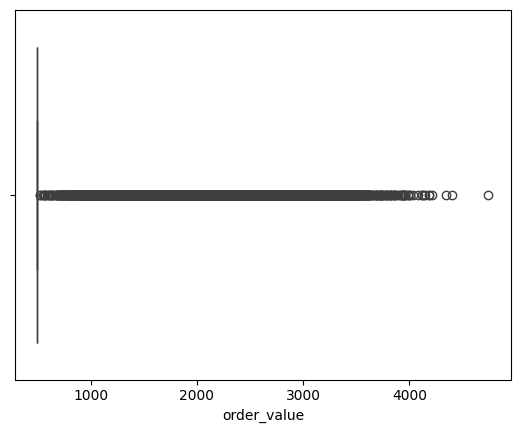

In [26]:
sns.boxplot(x = df['order_value'])


<Axes: xlabel='revenue'>

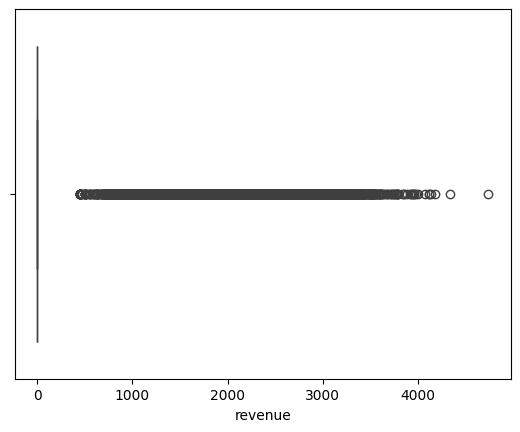

In [27]:
sns.boxplot(x =df['revenue'])

In [28]:
# IQR method

Q1 = df['order_value'].quantile(0.25)
Q3 = df['order_value'].quantile(0.75)

IQR = Q3 - Q1
IQR

# IQR = 0 ,in this case IQR method is not working to detect outliers

np.float64(0.0)

In [29]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1
IQR

# IQR = 0 ,in this case IQR method is not working to detect outliers

np.float64(0.0)

In [30]:
# count order value

df['order_value'].value_counts()

order_value
499     111843
2069        15
2302        14
2178        13
2101        12
         ...  
3278         1
1209         1
3636         1
3436         1
631          1
Name: count, Length: 2409, dtype: int64

<Axes: xlabel='order_value', ylabel='Count'>

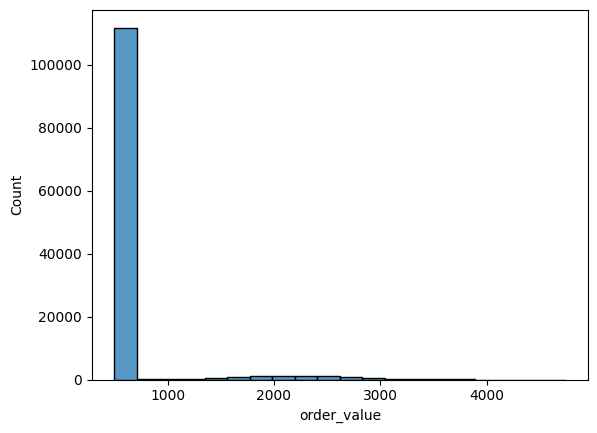

In [31]:
# crete histogram to check distribution of order value

sns.histplot(df['order_value'], bins=20)

In [32]:
# The order_value variable is highly concentrated at ₹499, with both the 25th and 75th percentiles equal to ₹499. 
# This indicates that most orders occur at the base price point, while a smaller proportion of transactions occur at higher price levels.

<Axes: xlabel='revenue', ylabel='Count'>

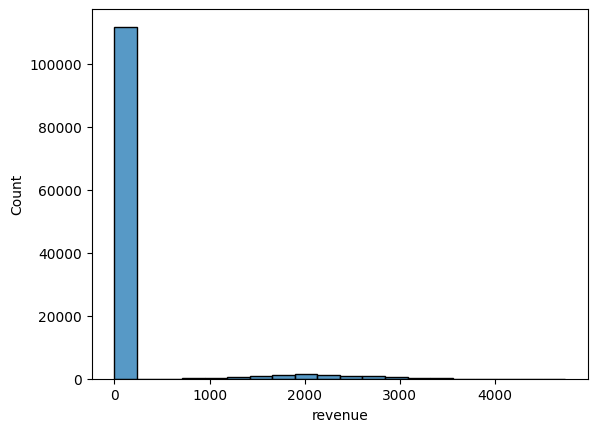

In [33]:
# for revenue outlier

sns.histplot(df['revenue'], bins=20)

In [34]:
# Revenue is highly right-skewed, with the majority of sessions generating no revenue and a small proportion contributing most sales.
# Because both Q1 and Q3 are equal, the IQR-based outlier detection method is not suitable for this variable.

Z-Score

In [35]:
# Rule for z-score :  z > 3 & z < -3 are outliers

outliers_order_value = df[(df['z-score_order_value'] > 3) | (df['z-score_order_value'] < -3)]
print(f"Number of outliers in order_value: {len(outliers_order_value)}")

KeyError: 'z-score_order_value'

In [ ]:
outliers_revenue = df[(df['z-score_revenue'] > 3) | (df['z-score_revenue'] < -3)]
print(f"Number of outliers in revenue: {len(outliers_revenue)}")

KeyError: 'z-score_revenue'

In [ ]:
df['z-score_order_value'] = stats.zscore(df['order_value'])
df['z-score_revenue'] = stats.zscore(df['revenue'])

df[['order_value','z-score_order_value','revenue','z-score_revenue']].head()

,order_value,z-score_order_value,revenue,z-score_revenue
0,499,-0.254241,0,-0.260027
1,499,-0.254241,0,-0.260027
2,499,-0.254241,0,-0.260027
3,2001,3.037851,1801,3.041666
4,499,-0.254241,0,-0.260027


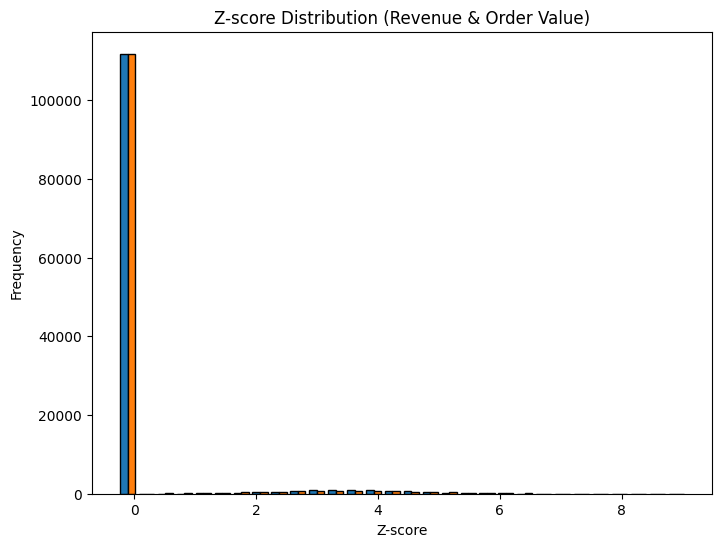

In [ ]:


plt.figure(figsize=(8,6))
plt.hist(df[['z-score_revenue', 'z-score_order_value']], bins=30, edgecolor='black')
plt.title("Z-score Distribution (Revenue & Order Value)")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.show()

Revenue is concentrated among a smaller subset of transactions, suggesting that high-value customers are unevenly distributed and a few users 
contribute disproportionately to total revenue.

In [36]:
for col in['channel' , 'campaign_type' , 'device' , 'user_type' , 'region']:
    
    print(f"\n{col}")
    print(df[col].unique())


channel
['Organic' 'Paid Ads' 'Social' 'Email']

campaign_type
['New Launch' 'Influencer' 'Discount']

device
['Mobile' 'Desktop']

user_type
['New' 'Returning']

region
['Metro' 'Non-Metro']


In [37]:
for col in['channel' , 'campaign_type' , 'device' , 'user_type' , 'region']:
    
    print(f"\n{col}")
    print(df[col].unique())


channel
['Organic' 'Paid Ads' 'Social' 'Email']

campaign_type
['New Launch' 'Influencer' 'Discount']

device
['Mobile' 'Desktop']

user_type
['New' 'Returning']

region
['Metro' 'Non-Metro']


In [38]:
	
for col in['visited_website','viewed_product','added_to_cart','checkout_started','purchase_completed','discount_applied']:
    
    print(f"\n{col}")
    print(df[col].unique())


visited_website
[1]

viewed_product
[0 1]

added_to_cart
[0 1]

checkout_started
[0 1]

purchase_completed
[0 1]

discount_applied
[0 1]


Analyze Categorical Variables

In [39]:
# channel

df['channel'].value_counts()


channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

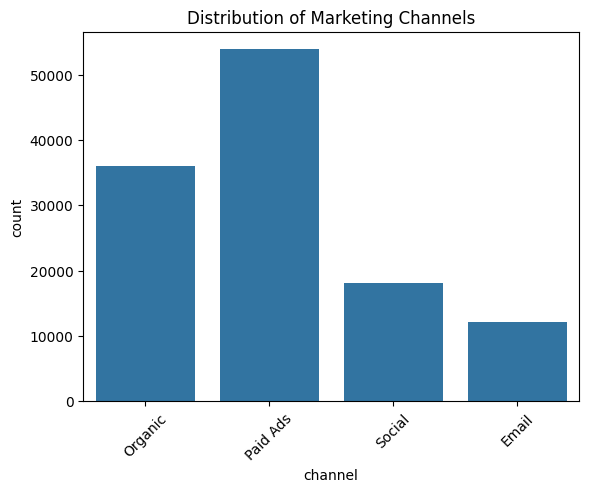

In [40]:
sns.countplot(x = 'channel', data = df)
plt.xticks(rotation = 45)
plt.title('Distribution of Marketing Channels')
plt.show

In [41]:
# campaign_type

df['campaign_type'].value_counts()

campaign_type
Discount      60121
New Launch    36064
Influencer    23815
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

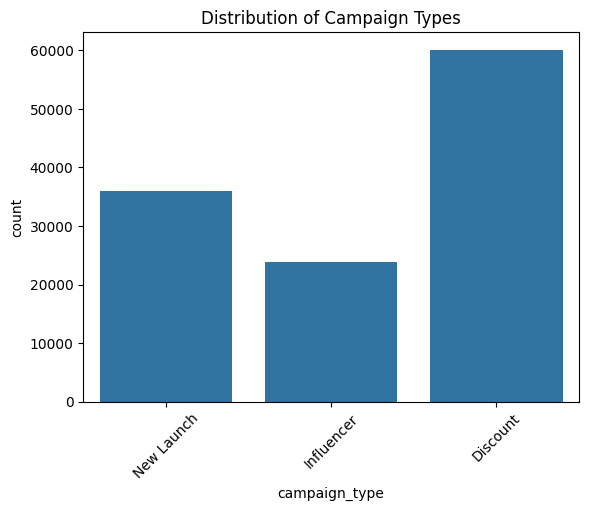

In [42]:
sns.countplot(x='campaign_type', data = df)
plt.xticks(rotation = 45)
plt.title('Distribution of Campaign Types')
plt.show

In [43]:
# device

df['device'].value_counts()

device
Mobile     84006
Desktop    35994
Name: count, dtype: int64

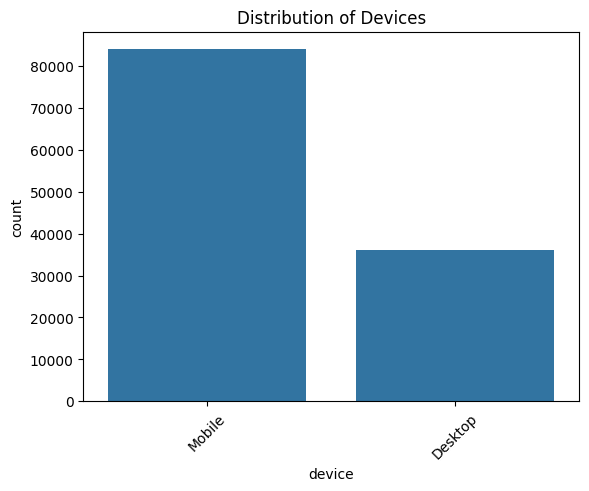

In [44]:
sns.countplot(x  = 'device', data = df)
plt.xticks(rotation = 45)
plt.title('Distribution of Devices')
plt.show()

In [45]:
# user_type

df['user_type'].value_counts()

user_type
New          77969
Returning    42031
Name: count, dtype: int64

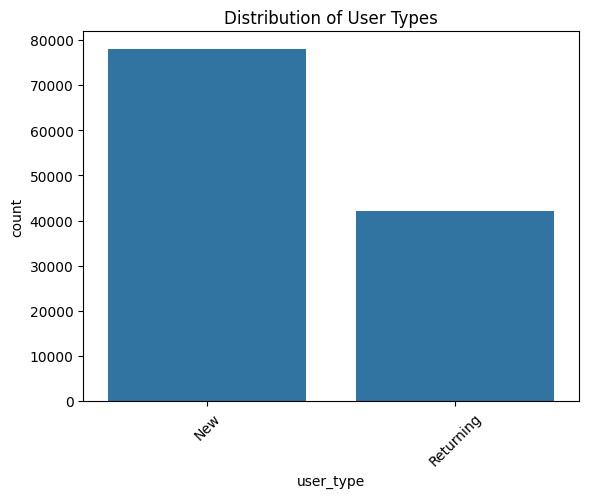

In [46]:
sns.countplot(x='user_type', data = df)
plt.xticks(rotation = 45)
plt.title('Distribution of User Types')
plt.show()

Funnel Analysis


In [47]:
stage = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed'
]


for stage in stage:
    print(stage, df[stage].eq(1).sum())

visited_website 120000
viewed_product 77870
added_to_cart 27156
checkout_started 16234
purchase_completed 8181


Coversion  Rate

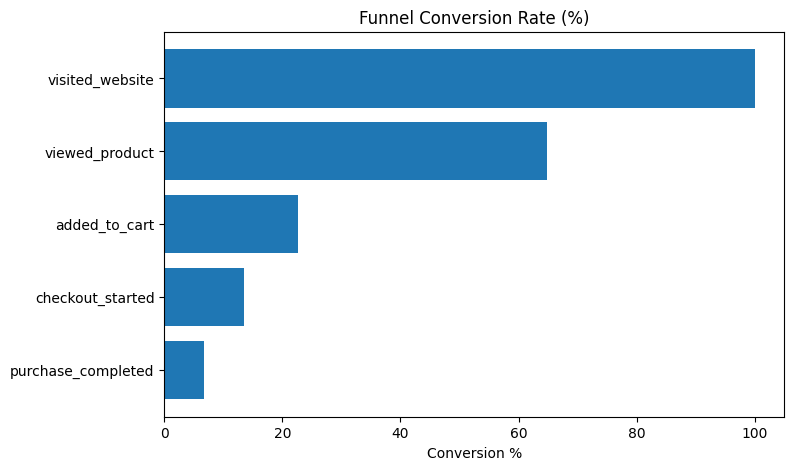

In [48]:
stages = [
    'visited_website',
    'viewed_product',
    'added_to_cart',
    'checkout_started',
    'purchase_completed'
]

values = [120000, 77870, 27156, 16234, 8181]

percentages = [v / values[0] * 100 for v in values]

plt.figure(figsize=(8,5))
plt.barh(stages, percentages)
plt.xlabel("Conversion %")
plt.title("Funnel Conversion Rate (%)")
plt.gca().invert_yaxis()
plt.show()

In [49]:
visits = df['visited_website'].eq(1).sum()
purchases = df['purchase_completed'].eq(1).sum()

conversion_rate = purchases / visits * 100
print(f"Conversion Rate: {conversion_rate:.2f}%")

Conversion Rate: 6.82%


Revenue Analysis

In [50]:
Total_revenue = df['revenue'].sum()
print(f"Total Revenue: ₹{Total_revenue:,.2f}")

Total Revenue: ₹17,020,678.00


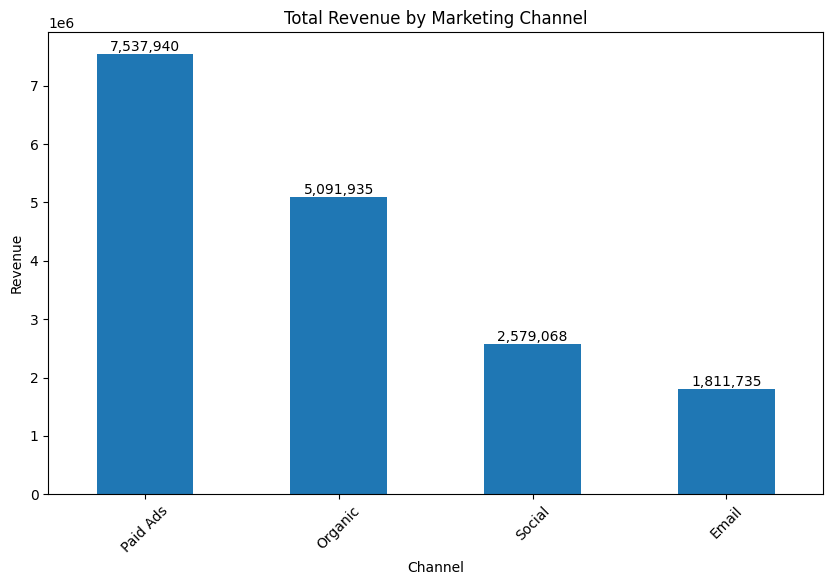

In [51]:
# revenue_by_channel

revenue_by_channel = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

ax = revenue_by_channel.plot(kind='bar', figsize=(10,6))

plt.title('Total Revenue by Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue')

# Add value labels on top of bars
for i, value in enumerate(revenue_by_channel):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

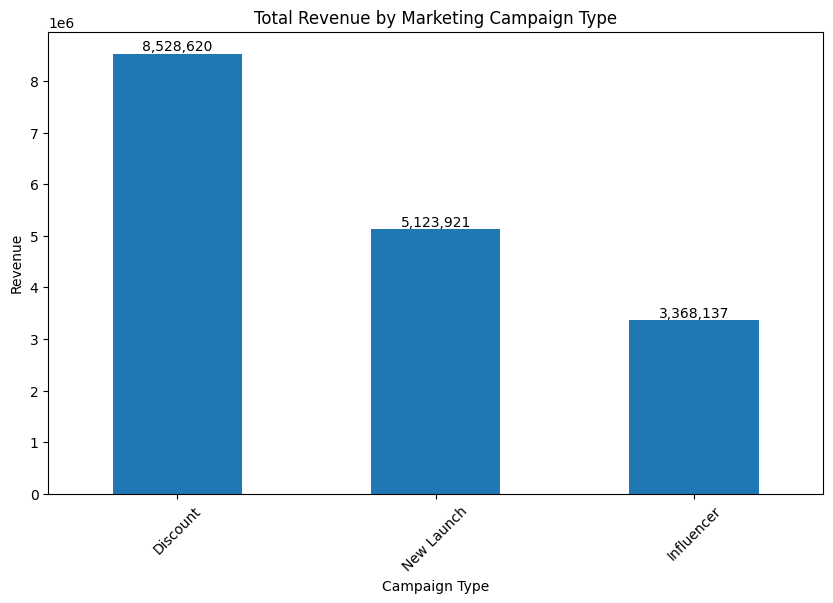

In [52]:
# revenue_by_campaign_type 

revenue_by_campaign_type = df.groupby('campaign_type')['revenue'].sum().sort_values(ascending=False)

ax = revenue_by_campaign_type.plot(kind='bar', figsize=(10,6))

plt.title('Total Revenue by Marketing Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Revenue')

# Add value labels on top of bars
for i, value in enumerate(revenue_by_campaign_type):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

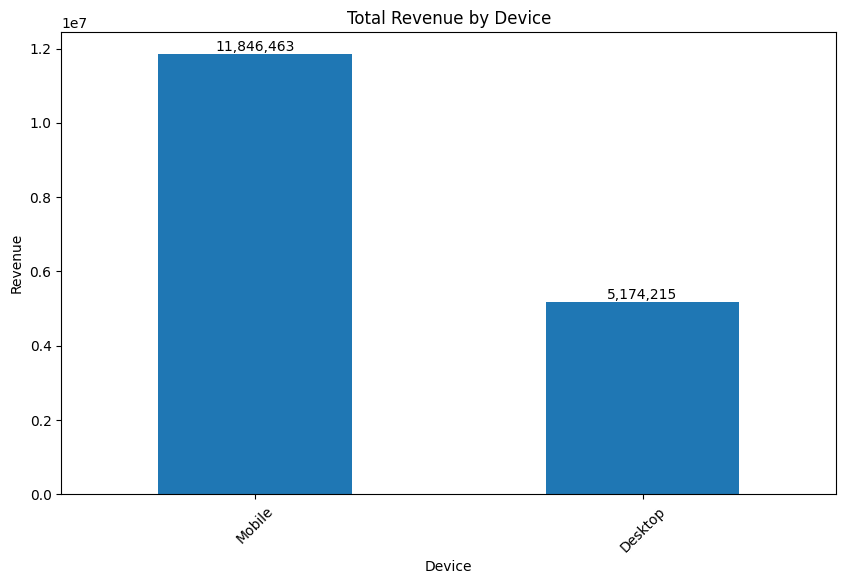

In [53]:
# revenue_by_device

revenue_by_device = df.groupby('device')['revenue'].sum().sort_values(ascending=False)

ax = revenue_by_device.plot(kind='bar', figsize=(10,6))

plt.title('Total Revenue by Device')
plt.xlabel('Device')
plt.ylabel('Revenue')

# Add value labels on top of bars
for i, value in enumerate(revenue_by_device):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

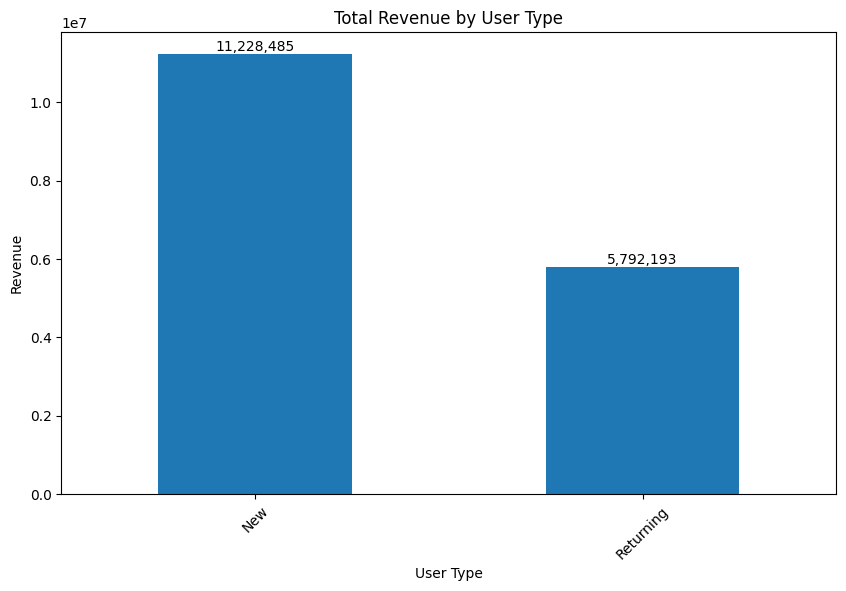

In [54]:
# revenue_by_user_type

revenue_by_user_type = df.groupby('user_type')['revenue'].sum().sort_values(ascending=False)

ax = revenue_by_user_type.plot(kind='bar', figsize=(10,6))

plt.title('Total Revenue by User Type')
plt.xlabel('User Type')
plt.ylabel('Revenue')

# Add value labels on top of bars
for i, value in enumerate(revenue_by_user_type):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

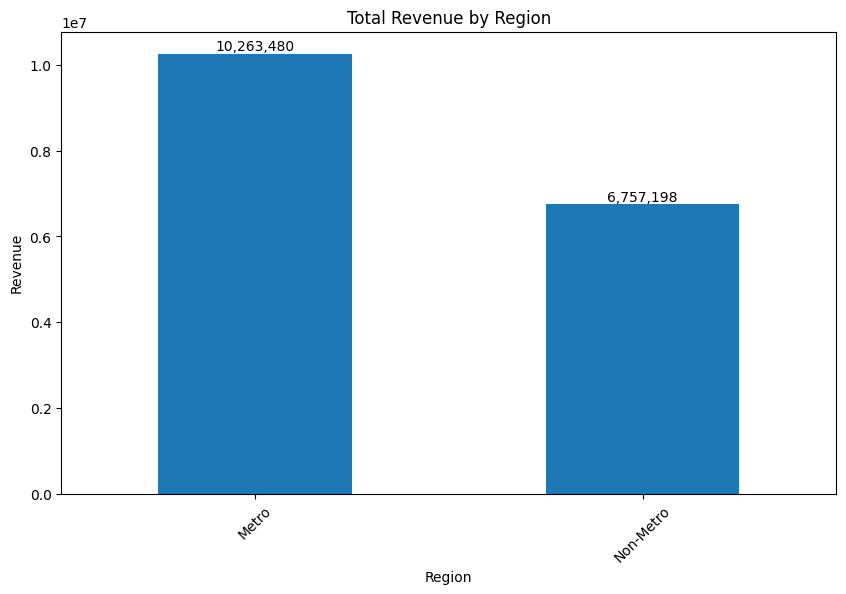

In [55]:
# revenue_by_region

revenue_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

ax = revenue_by_region.plot(kind='bar', figsize=(10,6))

plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

# Add value labels on top of bars
for i, value in enumerate(revenue_by_region):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

Monthly Trend Analysis

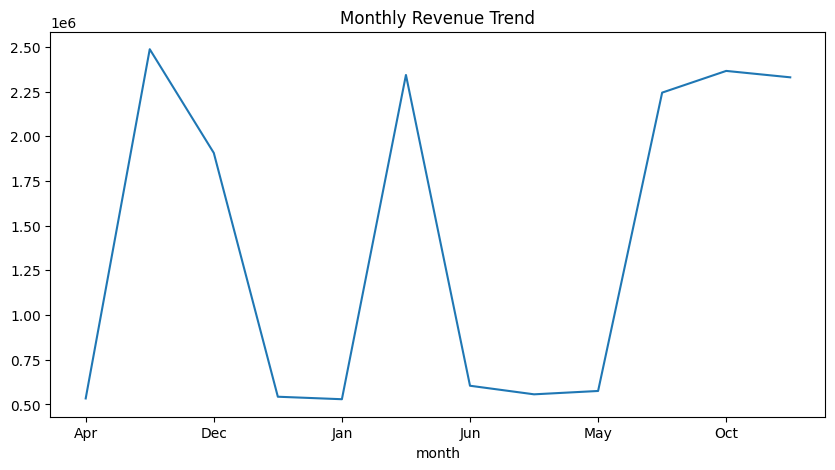

In [56]:
df.groupby('month')['revenue'].sum().plot(figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.show()

Propensity Target (Session-level)

In [57]:
df['propensity_target'] = df['purchase_completed']

LTV Target (Customer-level)

In [58]:
# Sort data
df = df.sort_values(['user_id', 'date'])

# Create LTV
ltv_df = (
    df.groupby('user_id')['revenue']
      .sum()
      .reset_index()
      .rename(columns={'revenue': 'ltv'})
)

print(ltv_df.head())
print("Number of users:", len(ltv_df))

   user_id   ltv
0   100005     0
1   100013  2009
2   100015     0
3   100025     0
4   100027  1477
Number of users: 112352


Feature Engineering

In [60]:
# Time Features

df['weekday'] = df['date'].dt.weekday

df['day_name'] = df['date'].dt.day_name()

df['month_num'] = df['date'].dt.month

df['quarter'] = df['date'].dt.quarter

df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)



In [63]:
# Journey Features

df['journey_score'] = (df['viewed_product'] 
                       + df['added_to_cart'] 
                       + df['checkout_started'])

df['journey_score']


17827     0
61380     3
16192     2
100336    1
84772     3
         ..
81150     0
13416     3
99121     2
30548     0
99573     3
Name: journey_score, Length: 120000, dtype: int64

In [64]:
# Behavioral Features

# Session Count per User
df['session_count'] = (df.groupby('user_id')['session_id']
                       .transform('count'))

# Purchase Count per User
df['purchase_count'] = (df.groupby('user_id')['purchase_completed']
                        .transform('sum'))

# Revenue per User
df['revenue_per_user'] = (df.groupby('user_id')['revenue']
                          .transform('sum'))


In [101]:
# Channel Interaction Features

# Channel × Device
df['channel_device'] = (
    df['channel'] + '_' + df['device']
)

# Channel × Region
df['channel_region'] = (
    df['channel'] + '_' + df['region']
)

# Campaign × User Type
df['campaign_user_type'] = (
    df['campaign_type'] + '_' + df['user_type']
)


df.head().reset_index(drop=True) 




,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,...,quarter,is_weekend,journey_score,session_count,purchase_count,revenue_per_user,channel_device,channel_region,campaign_user_type,discount_purchase_interaction
0,100005,17828,2025-07-14,Jul,Organic,Influencer,Mobile,New,Non-Metro,1,...,3,0,0,1,0,0,Organic_Mobile,Organic_Non-Metro,Influencer_New,0
1,100013,61381,2025-12-25,Dec,Paid Ads,Discount,Mobile,Returning,Non-Metro,1,...,4,0,3,1,1,2009,Paid Ads_Mobile,Paid Ads_Non-Metro,Discount_Returning,0
2,100015,16193,2025-07-16,Jul,Social,Influencer,Mobile,New,Non-Metro,1,...,3,0,2,1,0,0,Social_Mobile,Social_Non-Metro,Influencer_New,0
3,100025,100337,2025-12-08,Dec,Organic,Discount,Mobile,New,Metro,1,...,4,0,1,1,0,0,Organic_Mobile,Organic_Metro,Discount_New,0
4,100027,84773,2025-11-23,Nov,Organic,Discount,Mobile,Returning,Metro,1,...,4,1,3,1,1,1477,Organic_Mobile,Organic_Metro,Discount_Returning,0


In [98]:
# Additional Feature

# Discount Effect
df['discount_purchase_interaction'] = (
    df['discount_applied'] *
    df['purchase_completed']
)


In [102]:
# Check New Features
new_features = [
    'weekday',
    'day_name',
    'month',
    'is_weekend',
    'journey_score',
    'session_count',
    'purchase_count',
    'revenue_per_user',
    'channel_device',
    'channel_region',
    'campaign_user_type'
]

df[new_features].head().reset_index(drop=True)

,weekday,day_name,month,is_weekend,journey_score,session_count,purchase_count,revenue_per_user,channel_device,channel_region,campaign_user_type
0,0,Monday,Jul,0,0,1,0,0,Organic_Mobile,Organic_Non-Metro,Influencer_New
1,3,Thursday,Dec,0,3,1,1,2009,Paid Ads_Mobile,Paid Ads_Non-Metro,Discount_Returning
2,2,Wednesday,Jul,0,2,1,0,0,Social_Mobile,Social_Non-Metro,Influencer_New
3,0,Monday,Dec,0,1,1,0,0,Organic_Mobile,Organic_Metro,Discount_New
4,6,Sunday,Nov,1,3,1,1,1477,Organic_Mobile,Organic_Metro,Discount_Returning


Unique Users, Total_sessions, Total users visited

In [68]:
# unique users
print("Unique Users:", df['user_id'].nunique())

# total_sessions 
print("Total Sessions:", len(df))

# total users visited
print(df['user_id'].value_counts().describe())

Unique Users: 112352
Total Sessions: 120000
count    112352.000000
mean          1.068072
std           0.264992
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           5.000000
Name: count, dtype: float64


train-test Data


In [70]:
# confirm dates

print(df['date'].min())
print(df['date'].max())

2025-01-07 00:00:00
2025-12-27 00:00:00


In [71]:
# See records by month


month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
    'May':5, 'Jun':6, 'Jul':7, 'Aug':8,
    'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

df['month_num'] = df['month'].map(month_map)
df['month_num'].value_counts().sort_index()


month_num
1      3833
2      3984
3      4033
4      3955
5      3861
6      4028
7     16797
8     16588
9     16120
10    16657
11    16088
12    14056
Name: count, dtype: int64

In [72]:
# Create a time-based split


# Train on first 8 months:
train_df = df[df['month_num'] <= 9]

# Validate on months 9 and 10:
val_df = df[(df['month_num'] >= 9) & (df['month_num'] < 11)]

# Test on last 2 months:
test_df = df[df['month_num'] >= 11]

In [73]:
# Verify the split

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train months:")
print(sorted(train_df['month_num'].unique()))

print("Validation months:")
print(sorted(val_df['month_num'].unique()))

print("\nTest months:")
print(sorted(test_df['month_num'].unique()))


Train shape: (73199, 31)
Test shape: (30144, 31)
Train months:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Validation months:
[np.int64(9), np.int64(10)]

Test months:
[np.int64(11), np.int64(12)]


Create X and Y For propensity prediction:

In [74]:
target = 'purchase_completed'

features = [
    'viewed_product',
    'added_to_cart',    
    'checkout_started',
    'discount_applied',
    'journey_score'
]

X_train = train_df[features]
Y_train = train_df[target]

X_test = test_df[features]
Y_test = test_df[target]

In [75]:
# Train Logistic Regression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Make Predictions

In [76]:
# Class prediction (0 or 1)
y_pred = model.predict(X_test)

# Purchase probability
y_prob = model.predict_proba(X_test)[:,1]

print(y_pred)
print(y_prob)

[0 0 0 ... 0 0 0]
[3.20704346e-01 5.29324099e-05 3.20704346e-01 ... 5.29324099e-05
 3.20704346e-01 1.16772032e-04]


In [77]:
# Check target distribution

print(Y_train.value_counts())

print(Y_train.value_counts(normalize=True) * 100)

purchase_completed
0    68154
1     5045
Name: count, dtype: int64
purchase_completed
0    93.107829
1     6.892171
Name: proportion, dtype: float64


Check Accuracy

In [78]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9701101380042463


Classification Report

In [79]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     28139
           1       1.00      0.55      0.71      2005

    accuracy                           0.97     30144
   macro avg       0.98      0.78      0.85     30144
weighted avg       0.97      0.97      0.97     30144



Confusion Matrix

In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

print(cm)

[[28139     0]
 [  901  1104]]


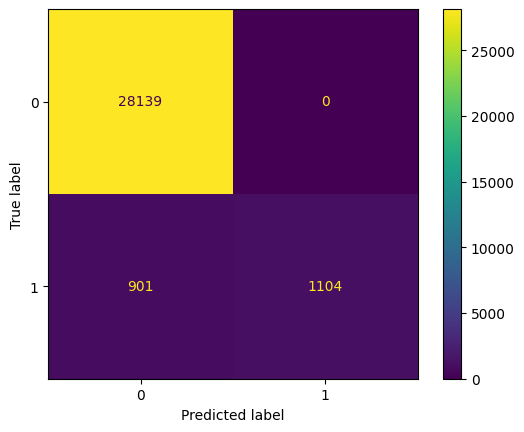

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred)

plt.show()

In [83]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(Y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9836787788161353


ROC Curve

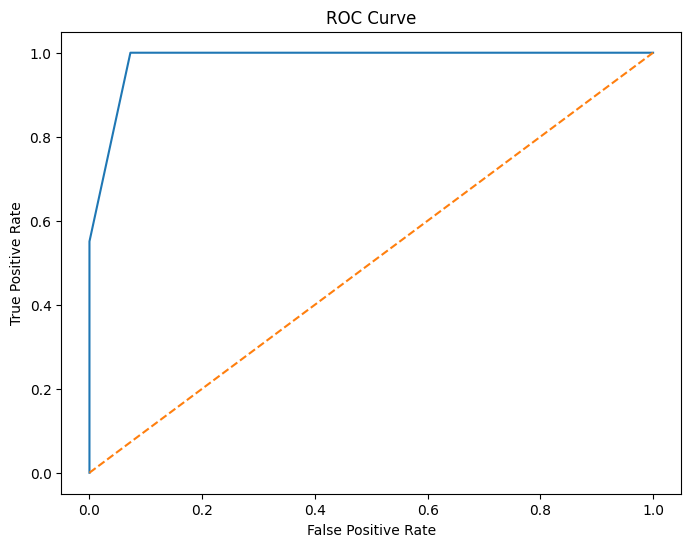

In [84]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

Precision-Recall Curve

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)

precision, recall, thresholds 

(array([0.06651407, 0.11464349, 0.29291454, 0.495184  , 1.        ,
        1.        ]),
 array([1.        , 1.        , 1.        , 1.        , 0.55062344,
        0.        ]),
 array([5.29324099e-05, 1.16772032e-04, 7.80977818e-04, 3.20704346e-01,
        9.98522757e-01]))

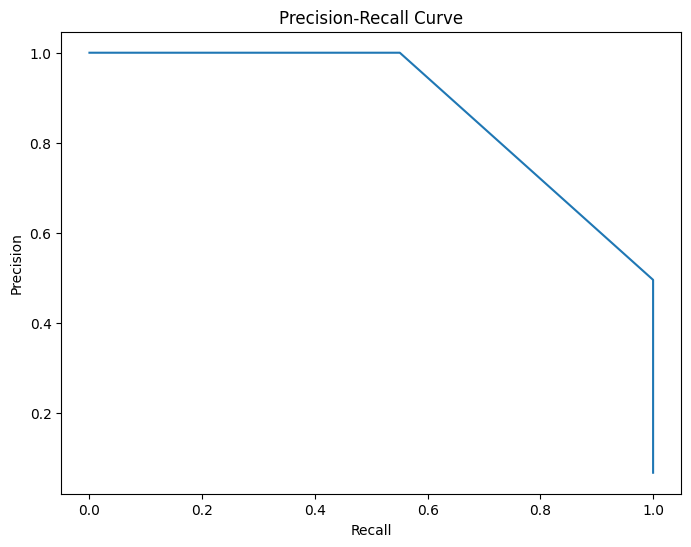

In [86]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

Feature Importance (Logistic Regression)

In [87]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

            Feature  Coefficient
3  discount_applied     7.266636
2  checkout_started     4.327487
4     journey_score     2.076158
1     added_to_cart     0.616101
0    viewed_product    -2.867430


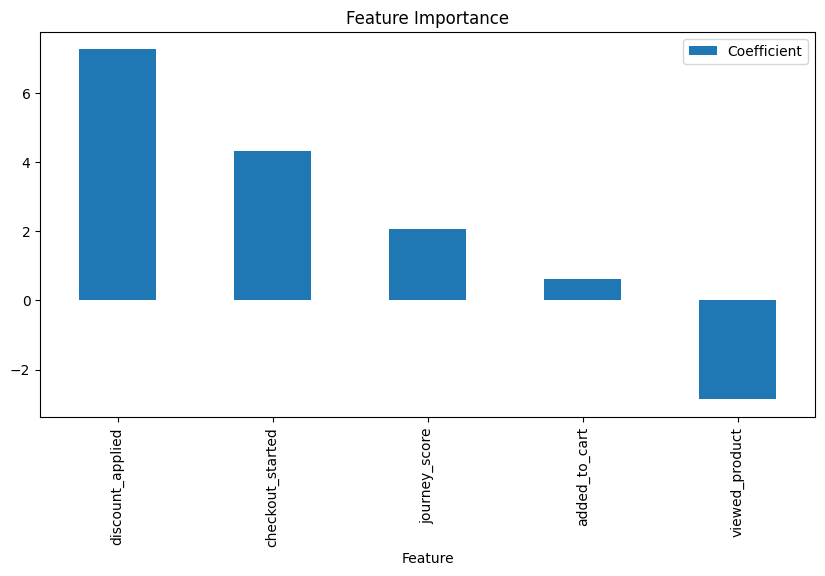

In [88]:
importance.plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.show()

Create Prediction Dataset

In [89]:
predictions = X_test.copy()

predictions['actual_purchase'] = Y_test.values

predictions['predicted_purchase'] = y_pred

predictions['purchase_probability'] = y_prob

In [103]:
predictions.head().reset_index(drop=True)

,viewed_product,added_to_cart,checkout_started,discount_applied,journey_score,actual_purchase,predicted_purchase,purchase_probability
0,1,1,1,0,3,1,0,0.320704
1,1,0,0,0,1,0,0,0.000053
2,1,1,1,0,3,1,0,0.320704
3,1,1,0,0,2,0,0,0.000781
4,1,0,0,0,1,0,0,0.000053


Export Predictions

In [104]:
predictions.to_csv(
    'propensity_predictions.csv',
    index=False
)